<a href="https://colab.research.google.com/github/hecfrantuis/Proyecto-IA-1/blob/main/Proyecto_AcneI_A1_Modelos_Supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drive - Librerias

In [1]:
#@title Montar el drive
import os
from google.colab import drive

Ubicacion = "Septimo/IA 1 2026-1/Proyecto/AcneDataset/train" #@param {type:"string"}
path = "/content/drive/My Drive/" + Ubicacion
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train


In [17]:
# @title Librerias
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from scipy.stats import zscore, entropy, stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, f_classif

# Seleccion de datos

In [20]:
# @title DataFrame con etiquetas
data = []

for etiqueta in os.listdir('.'):
    if os.path.isdir(etiqueta):
        for archivo in os.listdir(etiqueta):
            if archivo.endswith(('.jpg', '.png')):
                ruta_completa = os.path.join(etiqueta, archivo)
                img_bgr = cv2.imread(ruta_completa)

                if img_bgr is None:
                    continue

                # ── RGB ──────────────────────────────────────────────
                rojo   = np.mean(img_bgr[:, :, 2])
                verde  = np.mean(img_bgr[:, :, 1])
                azul   = np.mean(img_bgr[:, :, 0])
                contraste = img_bgr.std()

                # ── HSV (detecta inflamación y saturación) ────────────
                img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
                hue_mean = np.mean(img_hsv[:, :, 0])
                sat_mean = np.mean(img_hsv[:, :, 1])
                val_mean = np.mean(img_hsv[:, :, 2])

                # ── LBP — Local Binary Patterns (textura) ─────────────
                gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                lbp  = local_binary_pattern(gris, P=8, R=1, method='uniform')
                lbp_hist, _ = np.histogram(lbp.ravel(),
                                           bins=np.arange(0, 11),
                                           density=True)
                lbp_mean = np.mean(lbp)

                # ── Entropía (rugosidad / complejidad visual) ──────────
                # Histograma de la imagen en escala de grises → entropía
                hist_gris, _ = np.histogram(gris.ravel(), bins=256,
                                            range=(0, 256), density=True)
                hist_gris += 1e-10          # evitar log(0)
                entropia = entropy(hist_gris)

                data.append({
                    'Etiqueta'  : etiqueta,
                    'Rojo'      : rojo,
                    'Verde'     : verde,
                    'Azul'      : azul,
                    'Contraste' : contraste,
                    'Hue'       : hue_mean,
                    'Saturacion': sat_mean,
                    'Valor_HSV' : val_mean,
                    'LBP_Mean'  : lbp_mean,
                    'Entropia'  : entropia,
                })

df_proyecto = pd.DataFrame(data)
print(f"Dataset inicial: {df_proyecto.shape}")
print(df_proyecto['Etiqueta'].value_counts())

Dataset inicial: (2778, 10)
Etiqueta
Blackheads    735
Cyst          645
Papules       621
Pustules      584
Whiteheads    193
Name: count, dtype: int64


Dimensiones: X_scaled=(2778, 9) | y=(2778,)

Ranking de características:
   Feature    F_Score       P_Value
  Entropia 188.469600 4.638511e-143
 Valor_HSV 105.286800  1.337387e-83
      Rojo 103.745579  1.923212e-82
  LBP_Mean  89.618778  9.940607e-72
     Verde  74.602064  3.882311e-60
      Azul  70.574123  5.425725e-57
Saturacion  55.898714  2.109416e-45
 Contraste  22.571546  2.277749e-18
       Hue  21.193754  3.102531e-17


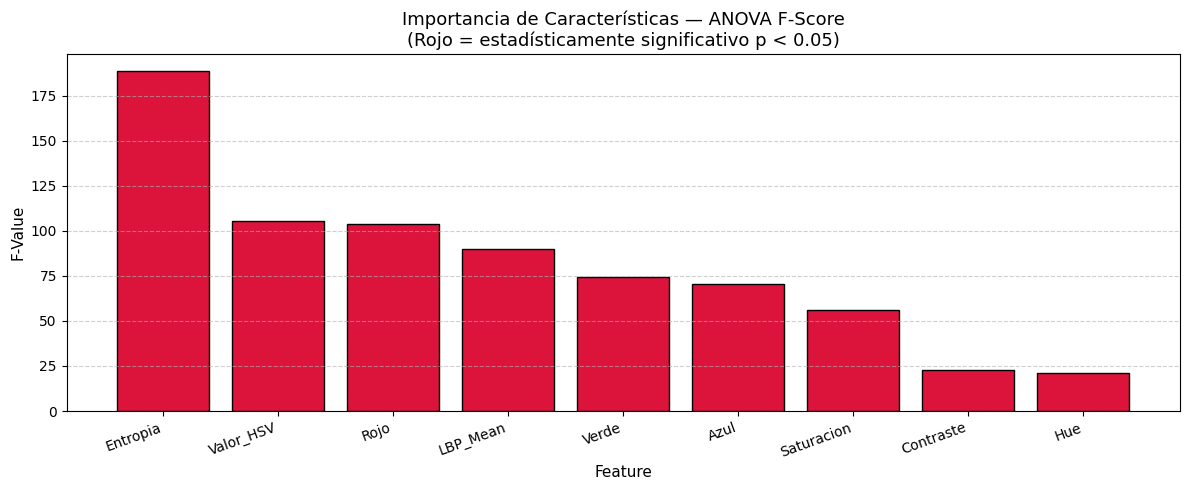

In [22]:
# @title Seleccion de las caracteristicas mas importantes
# Etiquetas
le = LabelEncoder()
df_proyecto['Etiqueta_Num'] = le.fit_transform(df_proyecto['Etiqueta'])

columnas_numericas = ['Rojo', 'Verde', 'Azul', 'Contraste',
                      'Hue', 'Saturacion', 'Valor_HSV', 'LBP_Mean', 'Entropia']

# Separamos X y y SIEMPRE desde df_proyecto
X = df_proyecto[columnas_numericas]          # features
y = df_proyecto['Etiqueta_Num']              # target (numérico)

# Escalamiento con RobustScaler (más robusto ante los outliers residuales)
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dimensiones: X_scaled={X_scaled.shape} | y={y.shape}")
# ▲ Deben coincidir — este era tu error: antes usabas 'y' (df_proyecto) en vez de y

# ── SelectKBest con ANOVA ─────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)          # ← y, NO y

# ── Visualización de importancia ──────────────────────────────────────────────
scores_df = pd.DataFrame({
    'Feature': columnas_numericas,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nRanking de características:")
print(scores_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colores = ['crimson' if p < 0.05 else 'steelblue'
           for p in scores_df['P_Value']]
plt.bar(scores_df['Feature'], scores_df['F_Score'],
        color=colores, edgecolor='black')
plt.title("Importancia de Características — ANOVA F-Score\n"
          "(Rojo = estadísticamente significativo p < 0.05)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("F-Value", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Seleccionamos las K mejores (ej. k=5) para el modelo final ────────────────
K_MEJOR = 5
selector_k = SelectKBest(score_func=f_classif, k=K_MEJOR)
X_final    = selector_k.fit_transform(X_scaled, y)
features_seleccionadas = np.array(columnas_numericas)[selector_k.get_support()]